# Model Training & Comparison
## Car Price Prediction

This notebook demonstrates training and comparing multiple machine learning models for car price prediction.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


## 1. Data Preparation

In [2]:
# Load data
df = pd.read_csv('../data/car_price_prediction_.csv')
print(f"Dataset shape: {df.shape}")

# Remove rows with missing values
df = df.dropna()
print(f"After removing NaN: {df.shape}")

# Remove outliers using IQR method
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Price'] >= Q1 - 1.5*IQR) & (df['Price'] <= Q3 + 1.5*IQR)]
print(f"After removing outliers: {df.shape}")

Dataset shape: (2500, 10)
After removing NaN: (2500, 10)
After removing outliers: (2500, 10)


In [3]:
# Separate target and features
X = df.drop('Price', axis=1)
y = df['Price']

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

Numerical features: ['Car ID', 'Year', 'Engine Size', 'Mileage']
Categorical features: ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']


In [4]:
# Encode categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nFinal feature set shape: {X.shape}")

Encoded Brand: {'Audi': 0, 'BMW': 1, 'Ford': 2, 'Honda': 3, 'Mercedes': 4, 'Tesla': 5, 'Toyota': 6}
Encoded Fuel Type: {'Diesel': 0, 'Electric': 1, 'Hybrid': 2, 'Petrol': 3}
Encoded Transmission: {'Automatic': 0, 'Manual': 1}
Encoded Condition: {'Like New': 0, 'New': 1, 'Used': 2}
Encoded Model: {'3 Series': 0, '5 Series': 1, 'A3': 2, 'A4': 3, 'Accord': 4, 'C-Class': 5, 'CR-V': 6, 'Camry': 7, 'Civic': 8, 'Corolla': 9, 'E-Class': 10, 'Explorer': 11, 'Fiesta': 12, 'Fit': 13, 'Focus': 14, 'GLA': 15, 'GLC': 16, 'Model 3': 17, 'Model S': 18, 'Model X': 19, 'Model Y': 20, 'Mustang': 21, 'Prius': 22, 'Q5': 23, 'Q7': 24, 'RAV4': 25, 'X3': 26, 'X5': 27}

Final feature set shape: (2500, 9)


In [5]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (2000, 9)
Test set: (500, 9)


## 2. Train Multiple Models

In [6]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)
}

print("Training models...\n")

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"{name}:")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE: ${mae:,.2f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print()

Training models...

Linear Regression:
  RMSE: $27,558.94
  MAE: $23,691.70
  R² Score: -0.0026
  CV R² (mean ± std): -0.0116 ± 0.0070

Random Forest:
  RMSE: $27,923.87
  MAE: $23,972.66
  R² Score: -0.0293
  CV R² (mean ± std): -0.0636 ± 0.0275

XGBoost:
  RMSE: $30,805.77
  MAE: $25,697.38
  R² Score: -0.2527
  CV R² (mean ± std): -0.2980 ± 0.0406

Gradient Boosting:
  RMSE: $27,614.78
  MAE: $23,492.13
  R² Score: -0.0066
  CV R² (mean ± std): -0.0578 ± 0.0261

AdaBoost:
  RMSE: $27,611.63
  MAE: $23,772.67
  R² Score: -0.0064
  CV R² (mean ± std): -0.0079 ± 0.0010



## 3. Model Comparison

In [7]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'R2': [results[m]['R2'] for m in results.keys()],
    'CV_R2': [results[m]['CV_Mean'] for m in results.keys()]
})

print("Model Comparison:")
print(comparison_df.to_string(index=False))

Model Comparison:
            Model         RMSE          MAE        R2     CV_R2
Linear Regression 27558.935447 23691.697185 -0.002563 -0.011568
    Random Forest 27923.871093 23972.662362 -0.029291 -0.063578
          XGBoost 30805.766731 25697.377352 -0.252711 -0.298046
Gradient Boosting 27614.775730 23492.131191 -0.006630 -0.057763
         AdaBoost 27611.634412 23772.666684 -0.006401 -0.007877


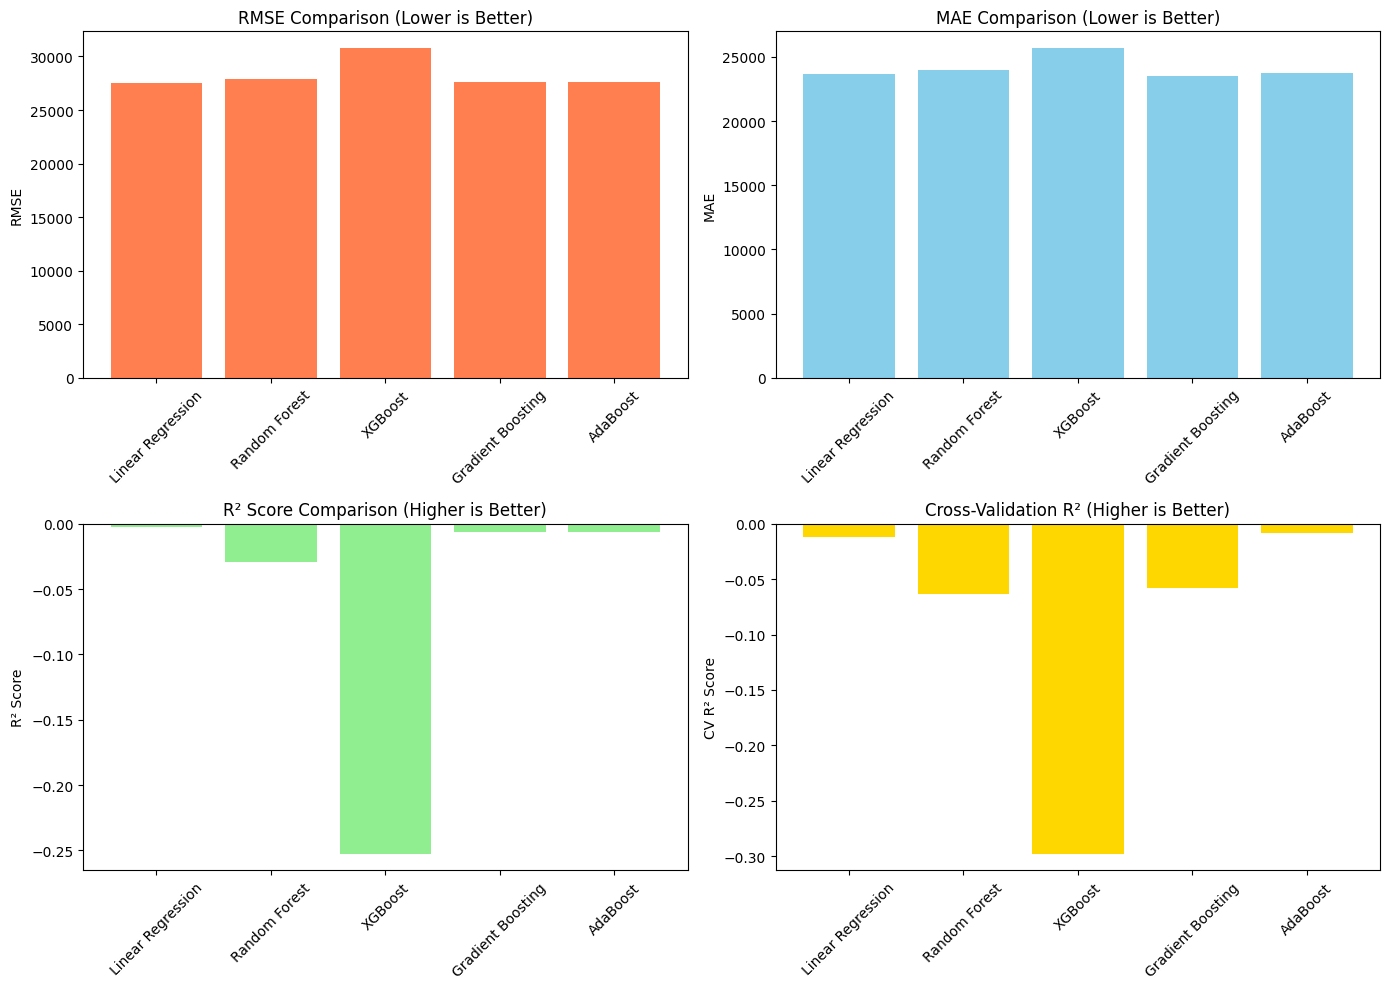

In [8]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE Comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['RMSE'], color='coral')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)

# MAE Comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['MAE'], color='skyblue')
axes[0, 1].set_title('MAE Comparison (Lower is Better)')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=45)

# R2 Comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['R2'], color='lightgreen')
axes[1, 0].set_title('R² Score Comparison (Higher is Better)')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].tick_params(axis='x', rotation=45)

# CV R2 Comparison
axes[1, 1].bar(comparison_df['Model'], comparison_df['CV_R2'], color='gold')
axes[1, 1].set_title('Cross-Validation R² (Higher is Better)')
axes[1, 1].set_ylabel('CV R² Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Feature Importance

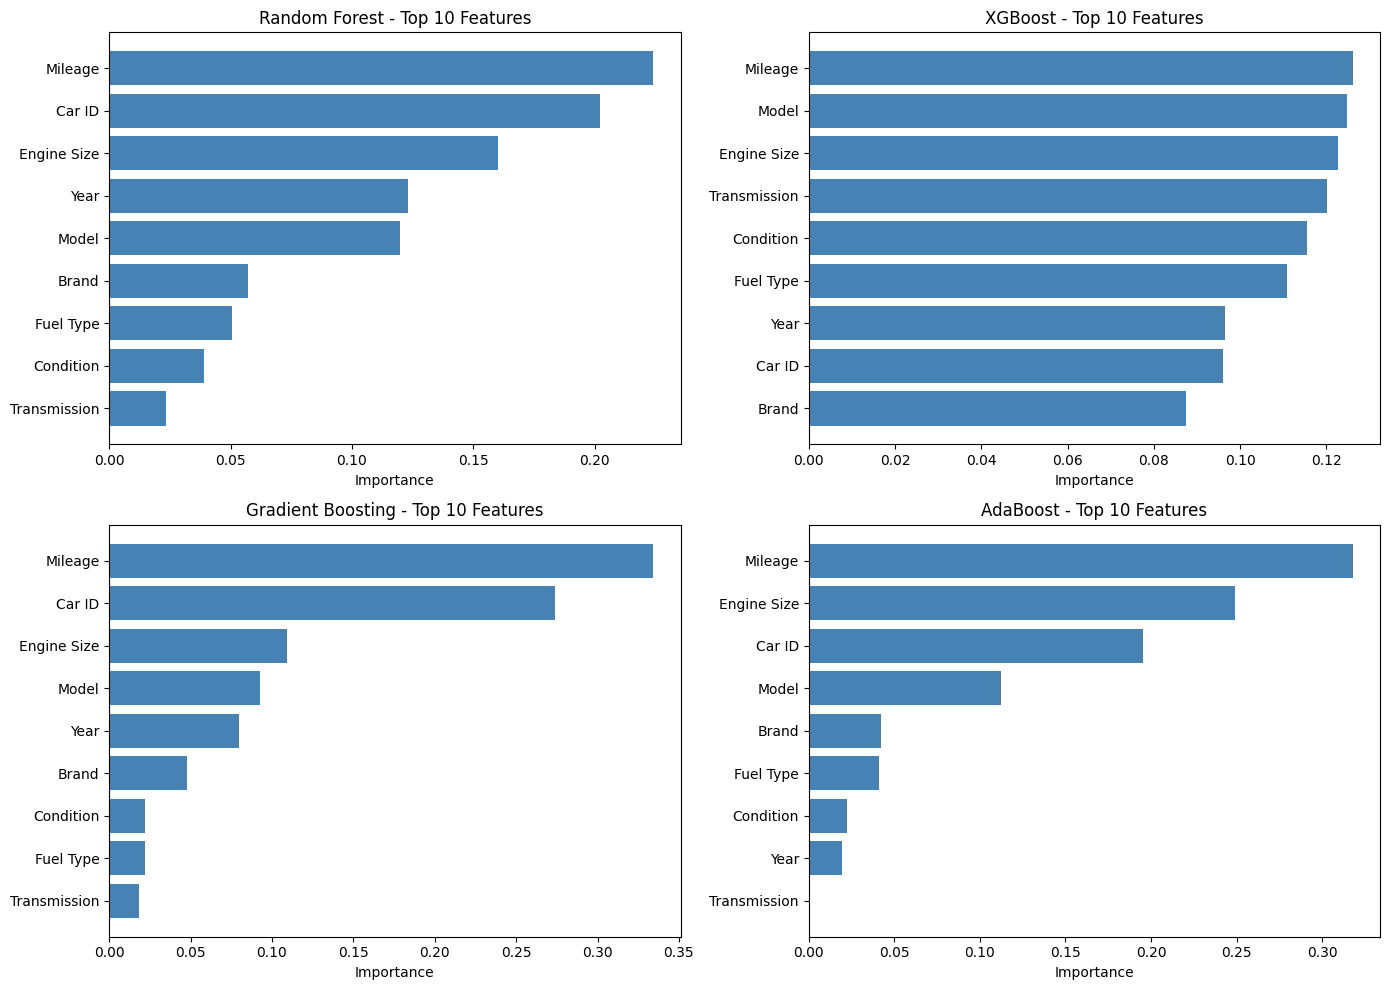

In [9]:
# Get feature importance from tree-based models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tree_models = ['Random Forest', 'XGBoost', 'Gradient Boosting', 'AdaBoost']
axes = axes.ravel()

for idx, model_name in enumerate(tree_models):
    model = results[model_name]['model']
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[-10:]
        
        axes[idx].barh(range(len(indices)), importances[indices], color='steelblue')
        axes[idx].set_yticks(range(len(indices)))
        axes[idx].set_yticklabels([X.columns[i] for i in indices])
        axes[idx].set_xlabel('Importance')
        axes[idx].set_title(f'{model_name} - Top 10 Features')

plt.tight_layout()
plt.show()

## 5. Best Model Performance

In [10]:
# Find best model by R2 score
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_model_name]['model']
best_r2 = results[best_model_name]['R2']

print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_name}")
print(f"R² Score: {best_r2:.4f}")
print(f"RMSE: ${results[best_model_name]['RMSE']:,.2f}")
print(f"MAE: ${results[best_model_name]['MAE']:,.2f}")
print(f"{'='*50}")


BEST MODEL: Linear Regression
R² Score: -0.0026
RMSE: $27,558.94
MAE: $23,691.70


In [ ]:
# Actual vs Predicted for best model
y_pred_best = results[best_model_name]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResiduals Statistics:")
print(f"Mean: {residuals.mean():.2f}")
print(f"Std Dev: {residuals.std():.2f}")
print(f"Min: {residuals.min():.2f}")
print(f"Max: {residuals.max():.2f}")